# Medical Health Data: Multimodal Acquisition, Cleaning, Preprocessing & Analysis

**Modalities**
- Part A — Tabular: Pima Indians Diabetes
- Part B — Text: MTSamples Medical Transcriptions
- Part C — Image: Chest X-Ray Images (Pneumonia)
- Part D — Signal: MIT-BIH Arrhythmia ECG

## Assignment goals covered
1. Data acquisition and inspection
2. Healthcare-specific cleaning
3. Modality-specific preprocessing into model-ready form
4. EDA
5. Hypothesis test, Chi-square test, and ANOVA for tabular data
6. Feature engineering, feature selection/extraction
7. Noise removal and augmentation where appropriate
8. Privacy / PHI / metadata considerations
9. Class imbalance and healthcare-specific data-quality discussion

In [3]:
!pip -q install kagglehub wfdb transformers imagehash

In [4]:
import os, re, json, math, random, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.signal import butter, filtfilt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

import torch

warnings.filterwarnings("ignore")
sns.set_context("notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Python ready")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python ready
Torch: 2.11.0+cpu
CUDA available: False


## Dataset acquisition

The three Kaggle datasets are public. `kagglehub` usually downloads public datasets directly in Colab.  
If Kaggle asks for authentication, create a Kaggle API token in your Kaggle account and upload `kaggle.json` to Colab.

MIT-BIH is loaded directly through `wfdb` from PhysioNet.

In [5]:
import kagglehub

PIMA_PATH = Path(kagglehub.dataset_download(
    "jamaltariqcheema/pima-indians-diabetes-dataset"
))
TEXT_PATH = Path(kagglehub.dataset_download(
    "tboyle10/medicaltranscriptions"
))
XRAY_PATH = Path(kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
))

print("Pima:", PIMA_PATH)
print("MTSamples:", TEXT_PATH)
print("Chest X-ray:", XRAY_PATH)

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Pima: /kaggle/input/pima-indians-diabetes-dataset
MTSamples: /kaggle/input/medicaltranscriptions
Chest X-ray: /kaggle/input/chest-xray-pneumonia


# Part A — Tabular Data: Pima Indians Diabetes

## Healthcare-specific issue
Several clinical measurements use `0` as a placeholder for missing data even though a true zero is physiologically implausible for variables such as glucose, blood pressure, skin thickness, insulin, and BMI.  
Those zeros must therefore be treated as missing values rather than ordinary observations.

In [6]:
# Locate and load the Pima CSV robustly
pima_csvs = list(PIMA_PATH.rglob("*.csv"))
print("CSV files:", pima_csvs)

pima_file = pima_csvs[0]
df = pd.read_csv(pima_file)

expected_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# Handle a headerless 9-column variant if encountered
if df.shape[1] == 9 and not set(expected_cols).issubset(df.columns):
    df = pd.read_csv(pima_file, header=None, names=expected_cols)

print("Shape:", df.shape)
display(df.head())
df.info()

CSV files: [PosixPath('/kaggle/input/pima-indians-diabetes-dataset/diabetes.csv')]
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [7]:
# Basic
display(df.describe(include="all").T)

print("\nDuplicate rows:", df.duplicated().sum())
print("\nRaw missing values:")
display(df.isna().sum().to_frame("missing"))

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



Duplicate rows: 0

Raw missing values:


,missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
# Clean duplicates
df = df.drop_duplicates().copy()

# Clinically implausible zero-as-missing variables
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_as_missing] == 0).sum().sort_values(ascending=False)
print("Clinically implausible zeros BEFORE cleaning:")
display(zero_counts.to_frame("zero_count"))

df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

print("\nMissing values AFTER converting impossible zeros to NaN:")
display(df.isna().sum().to_frame("missing"))

Clinically implausible zeros BEFORE cleaning:


,zero_count
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0



Missing values AFTER converting impossible zeros to NaN:


,missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


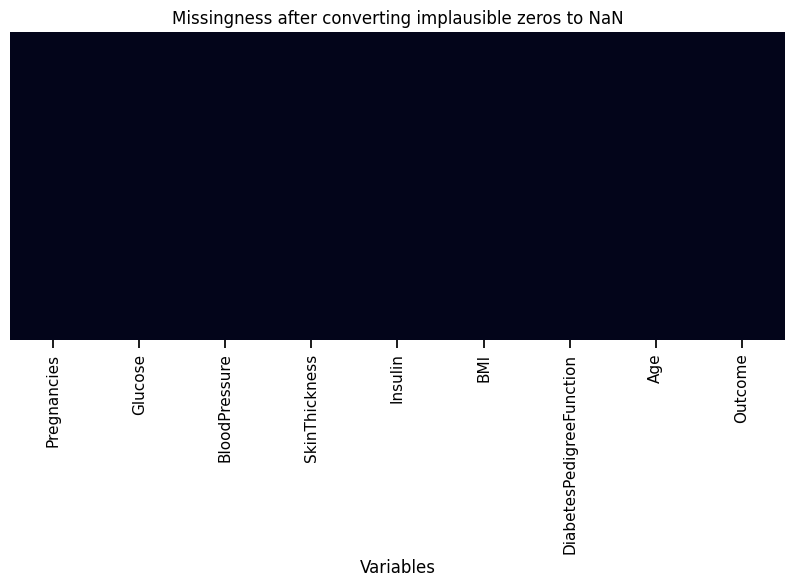

In [9]:
# Visualize missingness
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, yticklabels=False)
plt.title("Missingness after converting implausible zeros to NaN")
plt.xlabel("Variables")
plt.show()

In [10]:
# Median imputation - robust to skewed clinical variables
numeric_cols = df.select_dtypes(include=np.number).columns

for col in zero_as_missing:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:", int(df.isna().sum().sum()))
display(df.describe().T)

Missing values after imputation: 0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Outlier handling note
Clinical extremes can be real disease signals. Therefore, we **flag and inspect** outliers rather than automatically deleting every IQR outlier.

In [11]:
# IQR-based outlier flags for inspection
continuous_cols = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age"
]

outlier_summary = []
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append([col, lo, hi, int(n)])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["feature", "IQR_low", "IQR_high", "flagged_rows"]
)
display(outlier_df)

,feature,IQR_low,IQR_high,flagged_rows
0,Glucose,39.00,201.00,0
1,BloodPressure,40.00,104.00,14
2,SkinThickness,14.50,42.50,87
3,Insulin,2.00,270.00,51
4,BMI,13.85,50.25,8
5,DiabetesPedigreeFunction,-0.33,1.20,29
6,Age,-1.50,66.50,9


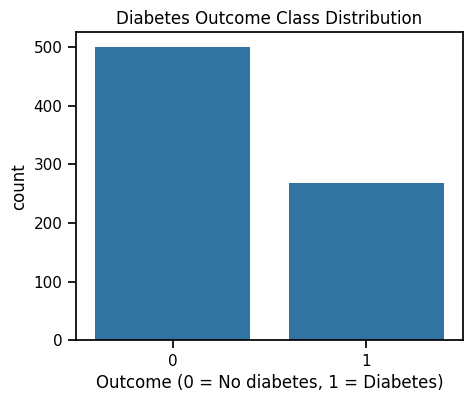

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [12]:
# EDA: target balance
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Outcome")
plt.title("Diabetes Outcome Class Distribution")
plt.xlabel("Outcome (0 = No diabetes, 1 = Diabetes)")
plt.show()

print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True).round(3))

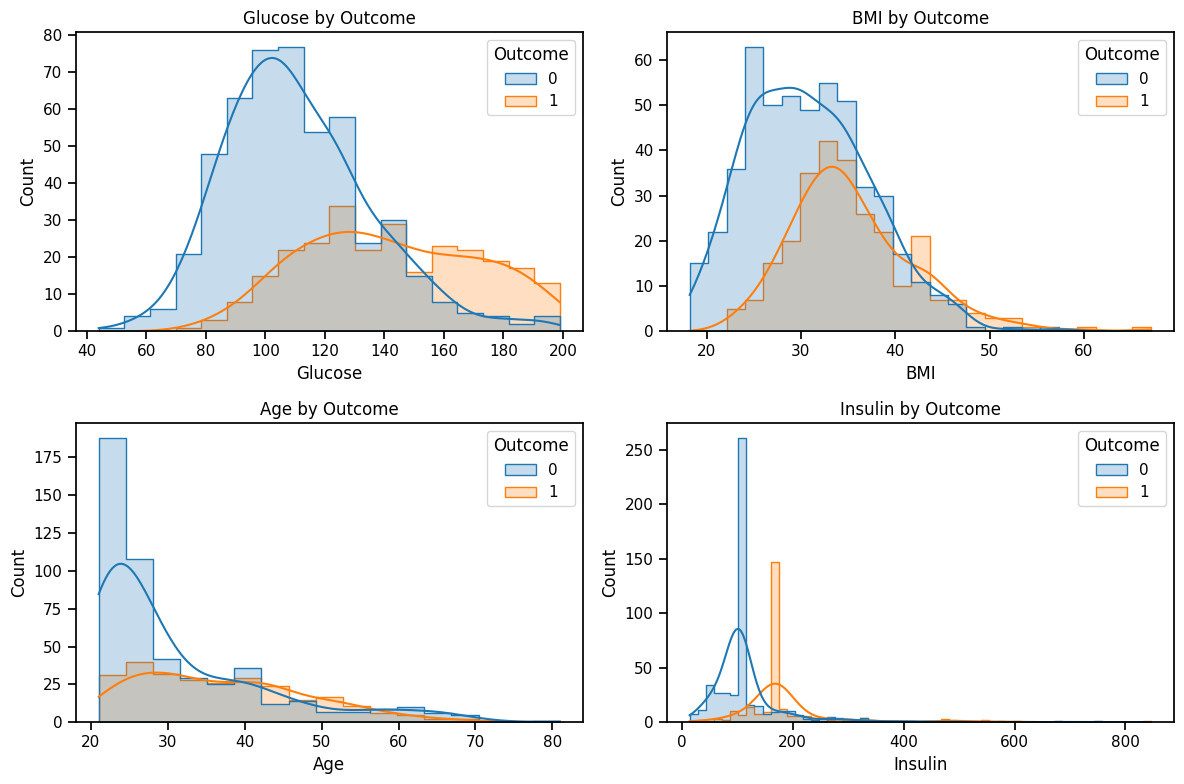

In [13]:
# EDA: distributions by outcome
features_to_plot = ["Glucose", "BMI", "Age", "Insulin"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), features_to_plot):
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, element="step", ax=ax)
    ax.set_title(f"{col} by Outcome")
plt.tight_layout()
plt.show()

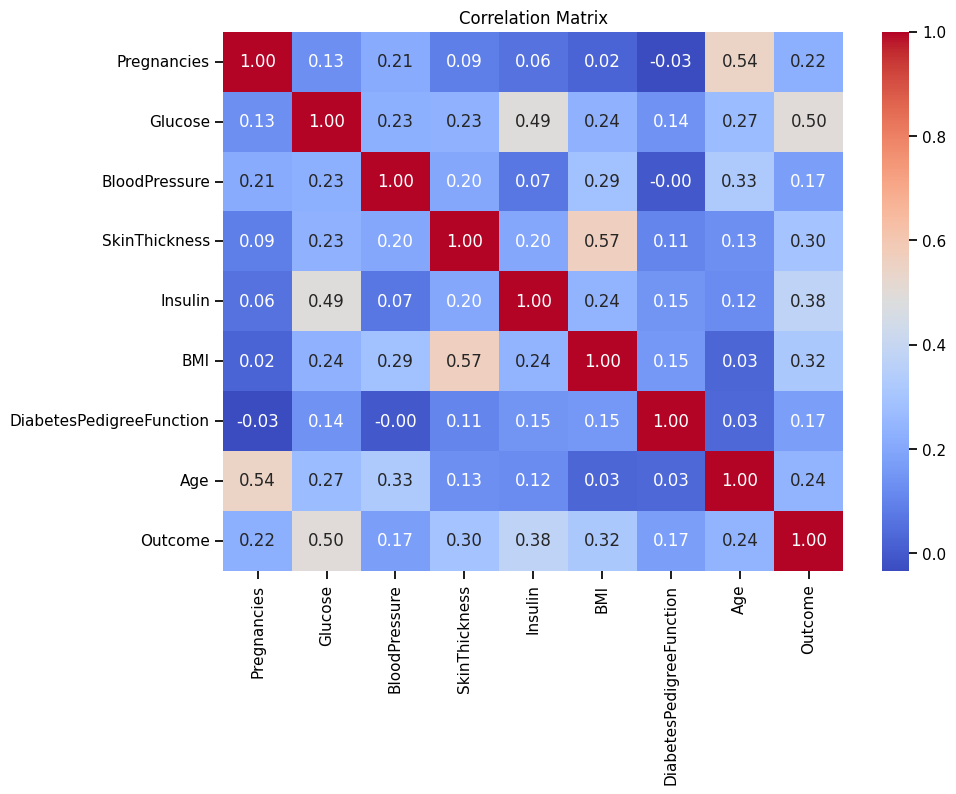

In [14]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Statistical Tests

For each test, use **α = 0.05**.

### 1. Hypothesis Test — Welch's independent t-test
**Question:** Is mean glucose significantly different between diabetic and non-diabetic patients?

- H0: Mean glucose is the same in both outcome groups.
- H1: Mean glucose differs between the groups.

In [15]:
alpha = 0.05

g0 = df.loc[df["Outcome"] == 0, "Glucose"]
g1 = df.loc[df["Outcome"] == 1, "Glucose"]

t_stat, p_value = stats.ttest_ind(g0, g1, equal_var=False)

print(f"Welch t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.6g}")
print("Decision:",
      "Reject H0" if p_value < alpha else "Fail to reject H0")

Welch t-statistic = -14.9921
p-value = 8.30177e-42
Decision: Reject H0


### 2. Chi-square Test of Independence
**Question:** Is BMI category associated with diabetes outcome?

- H0: BMI category and diabetes outcome are independent.
- H1: They are associated.

In [16]:
# WHO-style broad categories for demonstration
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    include_lowest=True
)

contingency = pd.crosstab(df["BMI_Category"], df["Outcome"])
display(contingency)

chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic = {chi2_stat:.4f}")
print(f"degrees of freedom = {dof}")
print(f"p-value = {chi2_p:.6g}")
print("Decision:",
      "Reject H0" if chi2_p < alpha else "Fail to reject H0")

expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)
print("\nExpected counts:")
display(expected_df.round(2))

Outcome,0,1
BMI_Category,,
Underweight,4,0
Normal,101,7
Overweight,136,44
Obese,259,217


Chi-square statistic = 73.1333
degrees of freedom = 3
p-value = 9.10166e-16
Decision: Reject H0

Expected counts:


Outcome,0,1
BMI_Category,,
Underweight,2.60,1.40
Normal,70.31,37.69
Overweight,117.19,62.81
Obese,309.90,166.10


### 3. One-way ANOVA
**Question:** Does mean glucose differ across age groups?

- H0: All age groups have the same mean glucose.
- H1: At least one age group has a different mean glucose.

In [17]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[20, 30, 40, 50, 60, np.inf],
    labels=["21-30", "31-40", "41-50", "51-60", "60+"],
    include_lowest=True
)

anova_groups = [
    grp["Glucose"].dropna().values
    for _, grp in df.groupby("Age_Group", observed=True)
    if len(grp) > 1
]

f_stat, anova_p = stats.f_oneway(*anova_groups)

print(f"ANOVA F-statistic = {f_stat:.4f}")
print(f"p-value = {anova_p:.6g}")
print("Decision:",
      "Reject H0" if anova_p < alpha else "Fail to reject H0")

display(
    df.groupby("Age_Group", observed=True)["Glucose"]
      .agg(["count", "mean", "std"])
      .round(2)
)

ANOVA F-statistic = 15.1263
p-value = 6.59592e-12
Decision: Reject H0


,count,mean,std
Age_Group,,,
21-30,417,114.94,27.04
31-40,157,127.07,31.82
41-50,113,126.12,32.68
51-60,54,141.15,31.34
60+,27,136.74,31.49


,feature,mutual_information
4,Insulin,0.336778
3,SkinThickness,0.140390
8,Glucose_BMI_Interaction,0.136030
1,Glucose,0.118467
10,BMI_Age_Interaction,0.105594
5,BMI,0.102162
7,Age,0.058849
2,BloodPressure,0.033002
0,Pregnancies,0.032941
9,Glucose_per_Age,0.012979


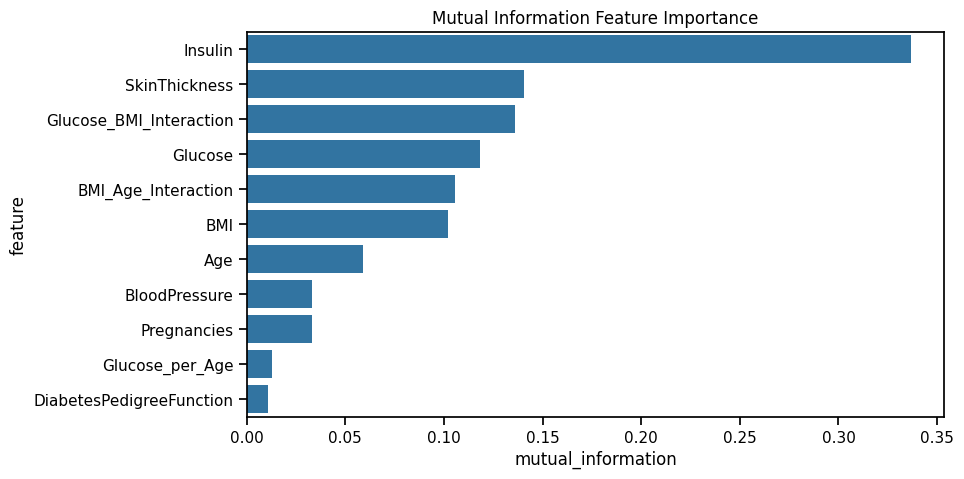

In [18]:
# Feature engineering
df["Glucose_BMI_Interaction"] = df["Glucose"] * df["BMI"]
df["Glucose_per_Age"] = df["Glucose"] / df["Age"].clip(lower=1)
df["BMI_Age_Interaction"] = df["BMI"] * df["Age"]

feature_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age",
    "Glucose_BMI_Interaction", "Glucose_per_Age", "BMI_Age_Interaction"
]

X = df[feature_cols].copy()
y = df["Outcome"].astype(int)

# Feature selection using mutual information
mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    "feature": feature_cols,
    "mutual_information": mi
}).sort_values("mutual_information", ascending=False)

display(mi_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=mi_df, x="mutual_information", y="feature")
plt.title("Mutual Information Feature Importance")
plt.show()

In [19]:
# Scale features and convert to model-ready tensors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

print("X tensor shape:", X_tensor.shape)
print("y tensor shape:", y_tensor.shape)
print("Tensor dtype:", X_tensor.dtype)

X tensor shape: torch.Size([768, 11])
y tensor shape: torch.Size([768])
Tensor dtype: torch.float32


# Part B — Textual Data: MTSamples Medical Transcriptions

Healthcare text can contain identifiers and quasi-identifiers.  
We will:
- remove missing/duplicate transcriptions,
- demonstrate PHI masking,
- normalize whitespace,
- inspect class imbalance,
- create TF-IDF features,
- perform feature selection,
- create transformer token sequences.

In [20]:
text_csvs = list(TEXT_PATH.rglob("*.csv"))
print(text_csvs)

mts_file = text_csvs[0]
mts = pd.read_csv(mts_file)

print("Shape:", mts.shape)
display(mts.head())
print("\nColumns:", mts.columns.tolist())
mts.info()

[PosixPath('/kaggle/input/medicaltranscriptions/mtsamples.csv')]
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."



Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [21]:
# Keep records with usable transcription text
mts = mts.copy()

if "transcription" not in mts.columns:
    raise ValueError("Expected a 'transcription' column in MTSamples.")

before = len(mts)
mts = mts.dropna(subset=["transcription"]).drop_duplicates(subset=["transcription"])
print("Rows removed due to missing/duplicate transcription:", before - len(mts))
print("Remaining rows:", len(mts))

Rows removed due to missing/duplicate transcription: 2642
Remaining rows: 2357


## PHI removal

The following rule-based function masks common PHI patterns such as emails, phone numbers, SSN-like numbers, dates, URLs, and medical-record-number-like strings.

This is a **demonstration**, not a production de-identification system. Real clinical de-identification should use validated NER/de-identification pipelines plus human review.

In [22]:
def mask_phi(text):
    text = str(text)

    patterns = [
        (r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', '[EMAIL]'),
        (r'\b(?:\+?1[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)\d{3}[-.\s]?\d{4}\b', '[PHONE]'),
        (r'\b\d{3}-\d{2}-\d{4}\b', '[SSN]'),
        (r'\b(?:https?://|www\.)\S+\b', '[URL]'),
        (r'\b(?:MRN|Medical Record|Record No\.?|Patient ID)\s*[:#-]?\s*[A-Za-z0-9-]+\b',
         '[MEDICAL_ID]'),
        (r'\b(?:0?[1-9]|1[0-2])[/-](?:0?[1-9]|[12]\d|3[01])[/-](?:19|20)?\d{2}\b',
         '[DATE]'),
    ]

    for pattern, repl in patterns:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)

    # Normalize whitespace while preserving clinical punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

mts["clean_text"] = mts["transcription"].apply(mask_phi)

display(mts[["transcription", "clean_text"]].head(3))

,transcription,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pre..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."


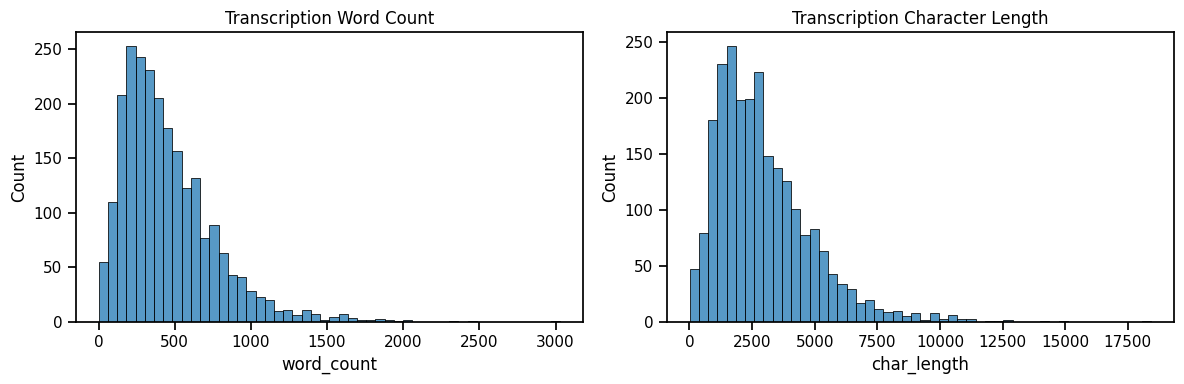

,count,mean,std,min,25%,50%,75%,max
word_count,2357.0,458.244803,315.206738,1.0,237.0,389.0,608.0,3029.0
char_length,2357.0,2974.420450,1968.831480,11.0,1548.0,2575.0,3904.0,18422.0


In [23]:
# Text EDA
mts["char_length"] = mts["clean_text"].str.len()
mts["word_count"] = mts["clean_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(mts["word_count"], bins=50, ax=axes[0])
axes[0].set_title("Transcription Word Count")

sns.histplot(mts["char_length"], bins=50, ax=axes[1])
axes[1].set_title("Transcription Character Length")
plt.tight_layout()
plt.show()

display(mts[["word_count", "char_length"]].describe().T)

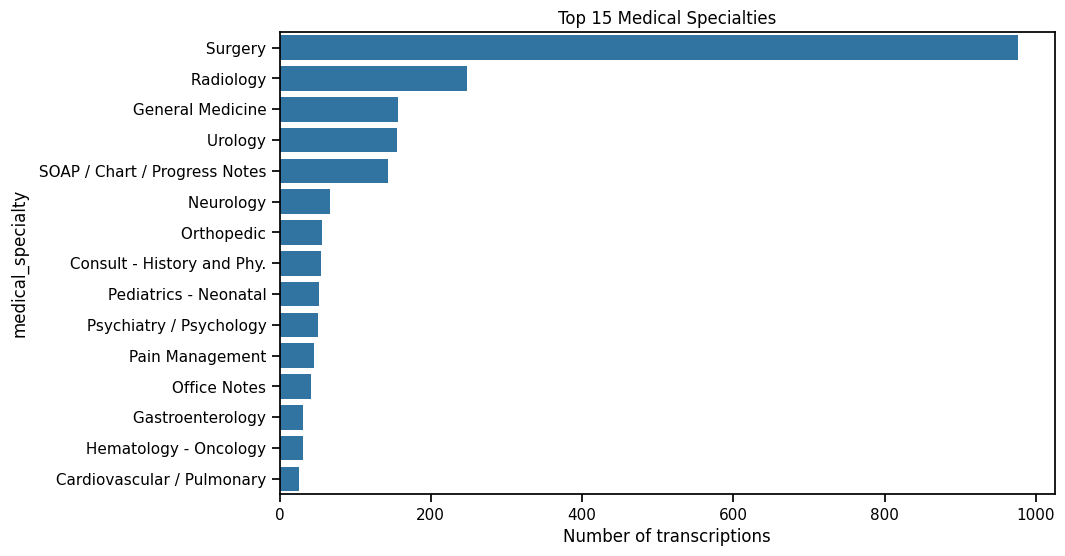

,count
medical_specialty,
Surgery,976
Radiology,248
General Medicine,157
Urology,156
SOAP / Chart / Progress Notes,144
Neurology,67
Orthopedic,56
Consult - History and Phy.,55
Pediatrics - Neonatal,52


In [24]:
# Medical-specialty class balance
if "medical_specialty" in mts.columns:
    top_specialties = mts["medical_specialty"].value_counts().head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_specialties.values, y=top_specialties.index)
    plt.title("Top 15 Medical Specialties")
    plt.xlabel("Number of transcriptions")
    plt.show()

    display(top_specialties.to_frame("count"))

In [25]:
# TF-IDF feature extraction
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(mts["clean_text"])
print("TF-IDF matrix shape:", X_tfidf.shape)

feature_names = np.array(tfidf.get_feature_names_out())

# Globally strongest terms by summed TF-IDF
scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_idx = scores.argsort()[-20:][::-1]

top_terms = pd.DataFrame({
    "term": feature_names[top_idx],
    "tfidf_sum": scores[top_idx]
})
display(top_terms)

TF-IDF matrix shape: (2357, 5000)


,term,tfidf_sum
0,patient,141.117865
1,right,86.596817
2,left,83.918224
3,history,80.246872
4,procedure,71.415647
5,normal,67.974988
6,placed,57.573345
7,pain,56.456496
8,mg,53.865080
9,noted,39.767363


In [26]:
# Supervised feature selection for specialty classification
# Use only specialties with >= 20 examples to reduce extreme sparsity.
if "medical_specialty" in mts.columns:
    specialty_counts = mts["medical_specialty"].value_counts()
    keep_specialties = specialty_counts[specialty_counts >= 20].index

    subset = mts[mts["medical_specialty"].isin(keep_specialties)].copy()
    X_sub = tfidf.transform(subset["clean_text"])
    y_sub = subset["medical_specialty"].astype(str)

    k = min(1000, X_sub.shape[1])
    selector = SelectKBest(score_func=chi2, k=k)
    X_selected = selector.fit_transform(X_sub, y_sub)

    selected_names = feature_names[selector.get_support()]
    print("Original TF-IDF shape:", X_sub.shape)
    print("Selected feature shape:", X_selected.shape)
    print("Example selected terms:", selected_names[:40])

Original TF-IDF shape: (2182, 5000)
Selected feature shape: (2182, 1000)
Example selected terms: ['10 mg' '18 gauge' '20 mg' '2006' '2007' '2008' '2009' '40 mg' '75'
 '80 mg' 'abc' 'abcd' 'abdomen' 'abdomen soft' 'abdominal pain' 'abuse'
 'activity' 'acute' 'acute distress' 'adenocarcinoma' 'adenopathy'
 'admission' 'admitted' 'afebrile' 'affect' 'age' 'ago' 'albumin'
 'albuterol' 'alcohol' 'alert' 'alert oriented' 'allergic'
 'allergic rhinitis' 'allergies' 'allergies known' 'allergies medications'
 'alt' 'amplitude' 'anemia']


In [27]:
# Model-ready token sequences using a biomedical-friendly transformer tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

sample_texts = mts["clean_text"].head(32).tolist()

tokens = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

print("input_ids:", tokens["input_ids"].shape)
print("attention_mask:", tokens["attention_mask"].shape)
print(tokens["input_ids"][0][:30])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

input_ids: torch.Size([32, 256])
attention_mask: torch.Size([32, 256])
tensor([  101, 20714,  1024,  1010,  2023,  2603,  1011,  2095,  1011,  2214,
         2317,  2931,  7534,  2007, 12087,  1997,  2035,  2121, 17252,  1012,
         2016,  2109,  2000,  2031,  2035,  2121, 17252,  2043,  2016,  2973])


### Text augmentation decision
Aggressive synonym replacement is intentionally avoided because changing a medical term can change clinical meaning.  
For this modality, the safer emphasis is **de-identification, normalization, tokenization, and feature extraction**. Augmentation is demonstrated more appropriately for the image and ECG modalities below.

# Part C — Image Data: Chest X-Ray Images (Pneumonia)

Healthcare-image issues addressed:
- unequal class sizes,
- variable image sizes/channels,
- metadata/privacy,
- exact duplicate detection,
- normalization,
- cautious noise removal,
- clinically conservative augmentation,
- pretrained CNN feature extraction.

In [28]:
# Find chest_xray root robustly
candidate_roots = [p for p in XRAY_PATH.rglob("chest_xray") if p.is_dir()]
if candidate_roots:
    chest_root = candidate_roots[0]
else:
    # Some KaggleHub layouts may expose train/test/val directly
    chest_root = XRAY_PATH

print("Chest root:", chest_root)

for split in ["train", "val", "test"]:
    split_dir = chest_root / split
    if split_dir.exists():
        print(split, {
            cls: len(list((split_dir / cls).glob("*")))
            for cls in ["NORMAL", "PNEUMONIA"]
            if (split_dir / cls).exists()
        })

Chest root: /kaggle/input/chest-xray-pneumonia/chest_xray
train {'NORMAL': 1341, 'PNEUMONIA': 3875}
val {'NORMAL': 8, 'PNEUMONIA': 8}
test {'NORMAL': 234, 'PNEUMONIA': 390}


In [29]:
# Collect image metadata
from PIL import Image, ExifTags

image_rows = []
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = chest_root / split / cls
        if not folder.exists():
            continue

        for fp in folder.glob("*"):
            if fp.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                continue
            try:
                with Image.open(fp) as im:
                    exif_count = len(im.getexif())
                    image_rows.append([
                        str(fp), split, cls,
                        im.width, im.height, im.mode, exif_count
                    ])
            except Exception:
                pass

img_meta = pd.DataFrame(
    image_rows,
    columns=["path", "split", "label", "width", "height", "mode", "exif_fields"]
)

print("Images indexed:", len(img_meta))
display(img_meta.head())
display(img_meta.groupby(["split", "label"]).size().rename("count").reset_index())

Images indexed: 5856


,path,split,label,width,height,mode,exif_fields
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,1336,1128,L,12
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,1400,1260,L,1
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,1218,1032,L,1
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,1782,1433,L,1
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,1574,1129,L,1


,split,label,count
0,test,NORMAL,234
1,test,PNEUMONIA,390
2,train,NORMAL,1341
3,train,PNEUMONIA,3875
4,val,NORMAL,8
5,val,PNEUMONIA,8


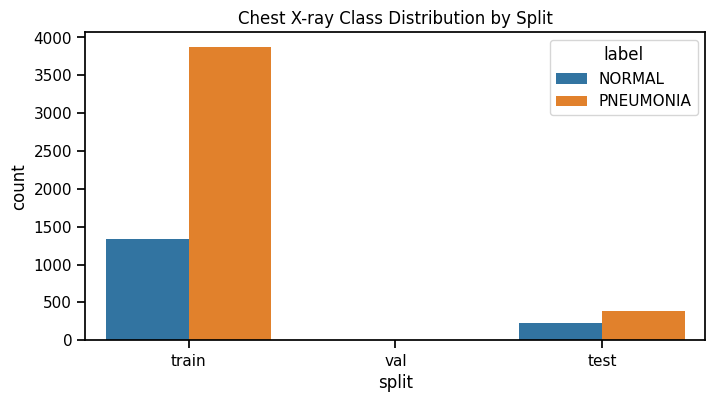

,count,mean,std,min,25%,50%,75%,max
width,5856.0,1327.880806,363.500922,384.0,1056.0,1281.0,1560.0,2916.0
height,5856.0,970.689037,383.392117,127.0,688.0,888.0,1187.0,2713.0
exif_fields,5856.0,0.667008,2.261498,0.0,0.0,0.0,1.0,12.0


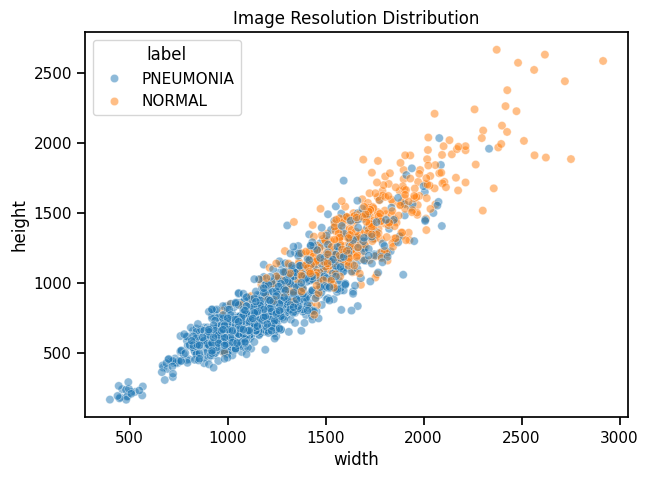

In [30]:
# EDA: class distribution
plt.figure(figsize=(8, 4))
sns.countplot(data=img_meta, x="split", hue="label")
plt.title("Chest X-ray Class Distribution by Split")
plt.show()

# Resolution statistics
display(img_meta[["width", "height", "exif_fields"]].describe().T)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=img_meta.sample(min(1500, len(img_meta)), random_state=RANDOM_STATE),
    x="width", y="height", hue="label", alpha=0.5
)
plt.title("Image Resolution Distribution")
plt.show()

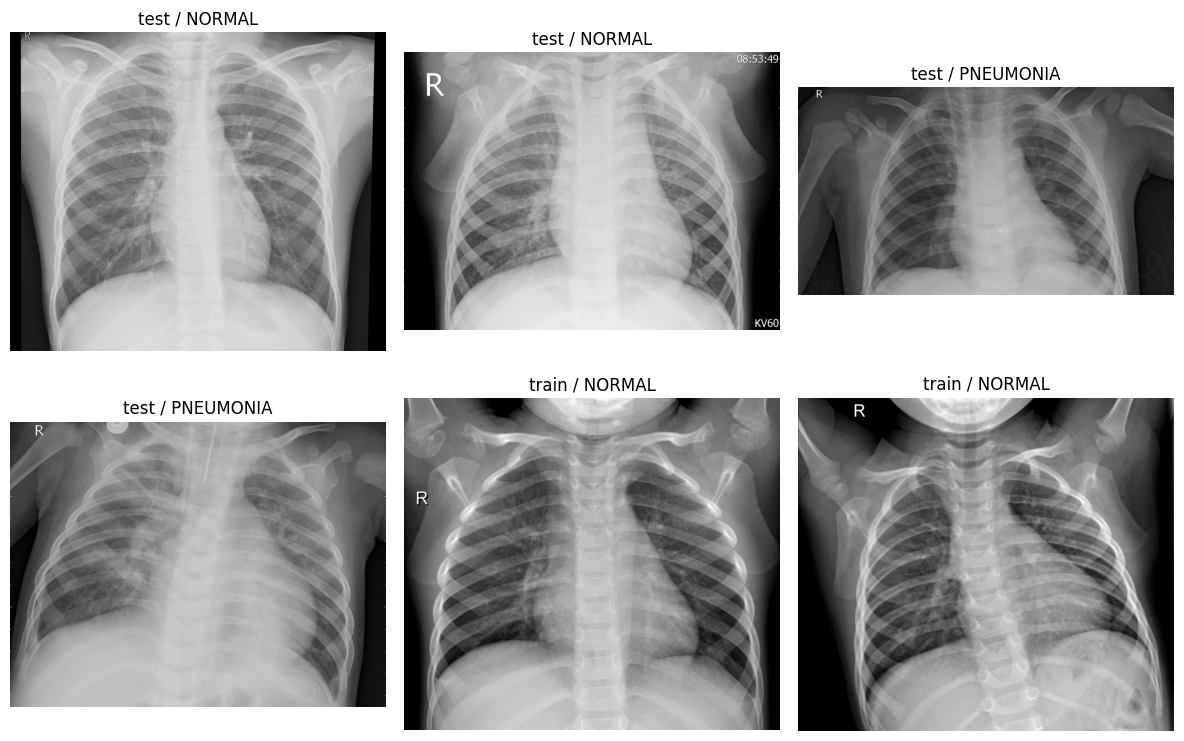

In [31]:
# Show representative images
sample_df = (
    img_meta.groupby(["split", "label"], group_keys=False)
    .apply(lambda x: x.sample(min(2, len(x)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.ravel(), sample_df.head(6).iterrows()):
    with Image.open(row["path"]) as im:
        ax.imshow(im, cmap="gray")
    ax.set_title(f'{row["split"]} / {row["label"]}')
    ax.axis("off")
plt.tight_layout()
plt.show()

## Imaging metadata anonymization

For model training, we load only pixel data and do not propagate EXIF metadata.  
If exporting cleaned copies, saving a newly created pixel image without the original EXIF block strips embedded metadata.

In [32]:
def anonymize_image_to_file(src_path, dst_path):
    with Image.open(src_path) as im:
        pixel_only = Image.fromarray(np.array(im.convert("L")))
        pixel_only.save(dst_path)  # no original EXIF copied

# Demonstration on one image
demo_src = Path(img_meta.iloc[0]["path"])
demo_dst = Path("/content/anonymized_demo.png")
anonymize_image_to_file(demo_src, demo_dst)

with Image.open(demo_src) as src_im, Image.open(demo_dst) as dst_im:
    print("Original EXIF fields:", len(src_im.getexif()))
    print("Clean copy EXIF fields:", len(dst_im.getexif()))
    print("Saved:", demo_dst)

Original EXIF fields: 12
Clean copy EXIF fields: 0
Saved: /content/anonymized_demo.png


In [33]:
# Exact duplicate detection using SHA-256
def file_sha256(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

# Hash all files (about 5.8k images; reasonable for this dataset)
img_meta["sha256"] = img_meta["path"].apply(file_sha256)

duplicate_hashes = img_meta["sha256"].value_counts()
duplicate_hashes = duplicate_hashes[duplicate_hashes > 1]

print("Number of exact duplicate hash groups:", len(duplicate_hashes))
if len(duplicate_hashes):
    display(
        img_meta[img_meta["sha256"].isin(duplicate_hashes.index)]
        .sort_values("sha256")
        .head(20)
    )

Number of exact duplicate hash groups: 30


,path,split,label,width,height,mode,exif_fields,sha256
3111,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,PNEUMONIA,1360,920,L,0,0033d6b3f444134e4d3a320b4c9e34cdbc4ffe1fdb9002...
2940,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,PNEUMONIA,1360,920,L,0,0033d6b3f444134e4d3a320b4c9e34cdbc4ffe1fdb9002...
3496,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,PNEUMONIA,1296,888,L,0,1679da3844455b96ea5e792b12d24a832c4dba570628c2...
2023,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,PNEUMONIA,1296,888,L,0,1679da3844455b96ea5e792b12d24a832c4dba570628c2...
5194,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,PNEUMONIA,1184,808,L,0,1e273d0058cfb3cf5fb401b74797903a3e66c75fd2dbd8...
2646,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,PNEUMONIA,1184,808,L,0,1e273d0058cfb3cf5fb401b74797903a3e66c75fd2dbd8...
821,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,2428,2540,L,1,3853a4552e0bc9aea1f45b2e7ee27be5954cdf9a0365d7...
1154,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,2428,2540,L,1,3853a4552e0bc9aea1f45b2e7ee27be5954cdf9a0365d7...
5437,/kaggle/input/chest-xray-pneumonia/chest_xray/...,test,NORMAL,1304,952,L,0,409f0f6c0f8a5b8ed4e0645633b07812aff5991aaee75b...
5422,/kaggle/input/chest-xray-pneumonia/chest_xray/...,test,NORMAL,1304,952,L,0,409f0f6c0f8a5b8ed4e0645633b07812aff5991aaee75b...


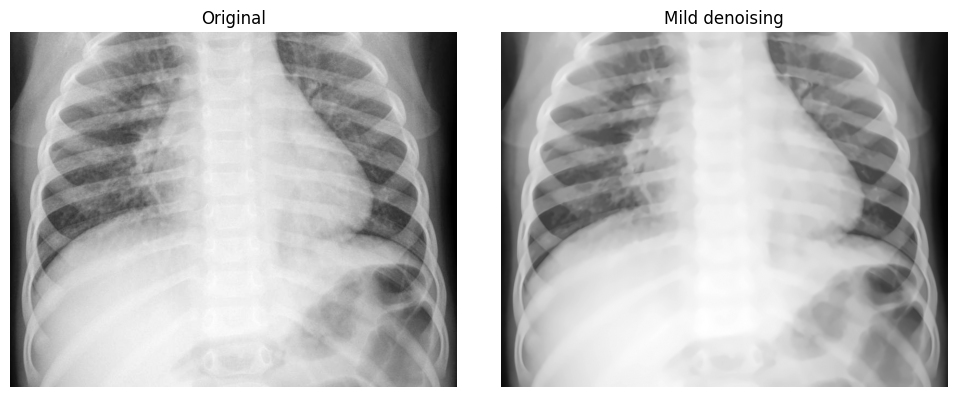

In [34]:
# Compare an original image with cautious denoising
import cv2

sample_path = img_meta.sample(1, random_state=RANDOM_STATE).iloc[0]["path"]
gray = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

# Mild non-local means denoising for demonstration
denoised = cv2.fastNlMeansDenoising(gray, None, h=5, templateWindowSize=7, searchWindowSize=21)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(denoised, cmap="gray")
axes[1].set_title("Mild denoising")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Image augmentation choice
We use mild rotation, translation, scale, and intensity changes.  
A horizontal flip is deliberately avoided because left-right orientation can be clinically meaningful in radiology.

In [35]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dir = chest_root / "train"
test_dir = chest_root / "test"

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))

print("Classes:", train_dataset.classes)
print("Image tensor batch:", images.shape)
print("Label tensor batch:", labels.shape)
print("Tensor range approx:", float(images.min()), float(images.max()))

Classes: ['NORMAL', 'PNEUMONIA']
Image tensor batch: torch.Size([32, 3, 224, 224])
Label tensor batch: torch.Size([32])
Tensor range approx: -2.1179039478302 2.640000104904175


In [36]:
# Handle class imbalance with class weights
class_counts = np.bincount(train_dataset.targets)
classes = np.arange(len(class_counts))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.array(train_dataset.targets)
)

class_weight_tensor = torch.tensor(weights, dtype=torch.float32)

print("Class counts:", dict(zip(train_dataset.classes, class_counts)))
print("Class weights:", dict(zip(train_dataset.classes, weights.round(3))))

Class counts: {'NORMAL': np.int64(1341), 'PNEUMONIA': np.int64(3875)}
Class weights: {'NORMAL': np.float64(1.945), 'PNEUMONIA': np.float64(0.673)}


In [37]:
# Feature extraction using a pretrained ResNet18
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet18_Weights.DEFAULT
feature_extractor = resnet18(weights=weights)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

with torch.no_grad():
    batch_features = feature_extractor(images.to(device))

print("CNN feature tensor shape:", batch_features.shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.3MB/s]


CNN feature tensor shape: torch.Size([32, 512])


# Part D — Signal Data: MIT-BIH Arrhythmia ECG

The MIT-BIH database contains annotated ambulatory ECG recordings.  
We will:
- acquire signals and annotations using WFDB,
- inspect raw ECG,
- remove baseline/high-frequency noise with a band-pass filter,
- segment beats around annotation locations,
- engineer time-domain/RR features,
- apply conservative signal augmentation,
- convert windows into model-ready tensors.

In [38]:
import wfdb

records = wfdb.get_record_list("mitdb")
print("Number of records:", len(records))
print("First 10:", records[:10])

Number of records: 48
First 10: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


In [39]:
# Load one record for inspection
record_name = "100"

record = wfdb.rdrecord(record_name, pn_dir="mitdb")
annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

signal = record.p_signal[:, 0].astype(float)
fs = int(record.fs)

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", fs, "Hz")
print("Signal names:", record.sig_name)
print("Number of beat annotations:", len(annotation.sample))
print("First annotation symbols:", annotation.symbol[:20])

Signal shape: (650000, 2)
Sampling frequency: 360 Hz
Signal names: ['MLII', 'V5']
Number of beat annotations: 2274
First annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


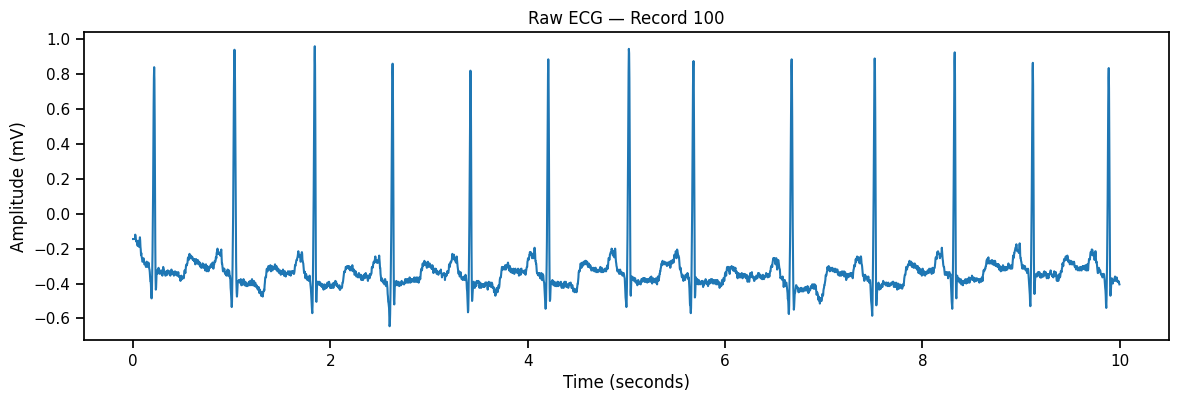

In [40]:
# Raw ECG EDA - first 10 seconds
seconds = 10
n = fs * seconds
t = np.arange(n) / fs

plt.figure(figsize=(14, 4))
plt.plot(t, signal[:n])
plt.title("Raw ECG — Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.show()

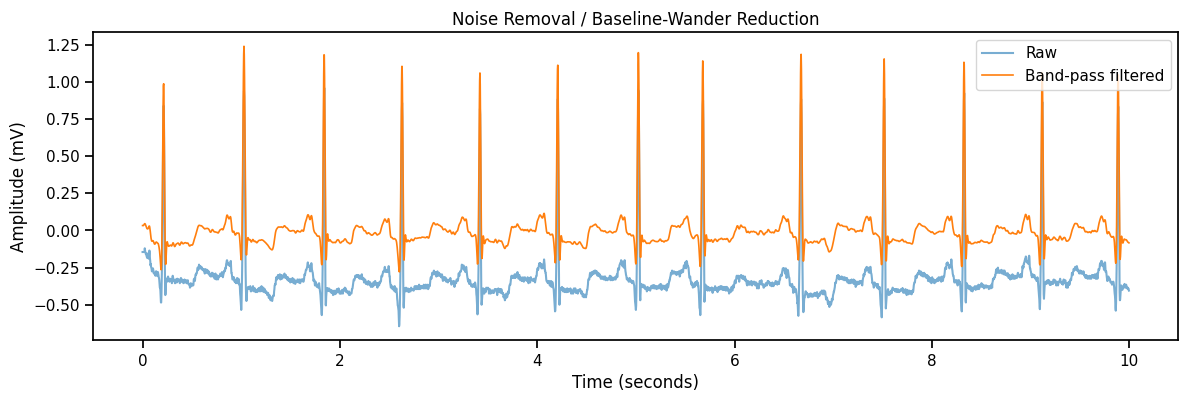

In [41]:
# Signal cleaning: interpolate missing values if any
ecg = pd.Series(signal).interpolate(limit_direction="both").to_numpy()

def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, x)

filtered_ecg = bandpass_filter(ecg, fs)

plt.figure(figsize=(14, 4))
plt.plot(t, ecg[:n], alpha=0.6, label="Raw")
plt.plot(t, filtered_ecg[:n], linewidth=1.2, label="Band-pass filtered")
plt.title("Noise Removal / Baseline-Wander Reduction")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

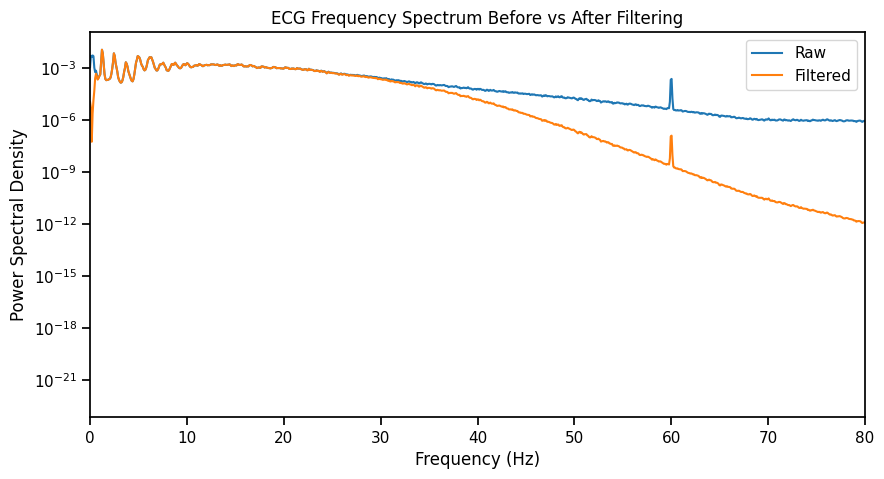

In [42]:
# Frequency-domain EDA
from scipy.signal import welch

freq_raw, psd_raw = welch(ecg, fs=fs, nperseg=min(4096, len(ecg)))
freq_filt, psd_filt = welch(filtered_ecg, fs=fs, nperseg=min(4096, len(filtered_ecg)))

plt.figure(figsize=(10, 5))
plt.semilogy(freq_raw, psd_raw, label="Raw")
plt.semilogy(freq_filt, psd_filt, label="Filtered")
plt.xlim(0, 80)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("ECG Frequency Spectrum Before vs After Filtering")
plt.legend()
plt.show()

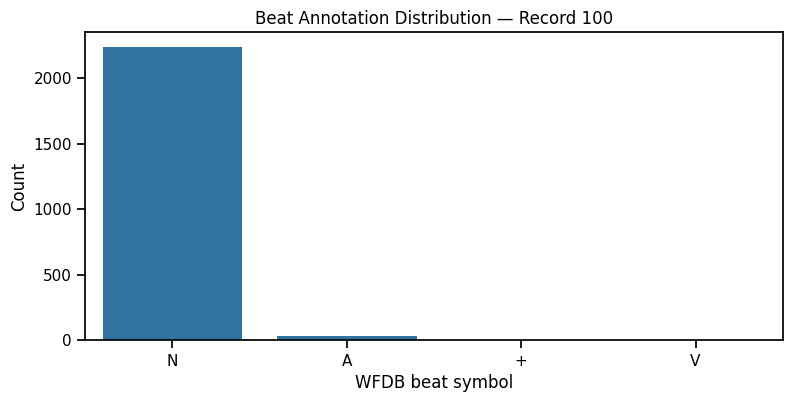

,count
N,2239
A,33
+,1
V,1


In [43]:
# Annotation class distribution for record 100
ann_counts = pd.Series(annotation.symbol).value_counts().head(15)

plt.figure(figsize=(9, 4))
sns.barplot(x=ann_counts.index, y=ann_counts.values)
plt.title("Beat Annotation Distribution — Record 100")
plt.xlabel("WFDB beat symbol")
plt.ylabel("Count")
plt.show()

display(ann_counts.to_frame("count"))

## Beat-window extraction

We extract a fixed window around each annotated beat:
- 0.25 s before the annotation
- 0.45 s after the annotation

Each window is z-normalized independently. Invalid edge windows and non-beat annotation symbols are skipped.

In [44]:
# Common beat symbols; excludes rhythm-change / noise annotation markers.
VALID_BEATS = {
    "N", "L", "R", "B", "A", "a", "J", "S",
    "V", "r", "F", "e", "j", "n", "E", "/", "f", "Q", "?"
}

def extract_windows_from_record(record_name, pre_s=0.25, post_s=0.45):
    rec = wfdb.rdrecord(record_name, pn_dir="mitdb")
    ann = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

    x = rec.p_signal[:, 0].astype(float)
    fs_local = int(rec.fs)

    x = pd.Series(x).interpolate(limit_direction="both").to_numpy()
    x = bandpass_filter(x, fs_local)

    pre = int(pre_s * fs_local)
    post = int(post_s * fs_local)

    windows, labels, peaks = [], [], []

    for sample_idx, symbol in zip(ann.sample, ann.symbol):
        if symbol not in VALID_BEATS:
            continue

        start = sample_idx - pre
        end = sample_idx + post

        if start < 0 or end > len(x):
            continue

        w = x[start:end].copy()
        sd = w.std()
        if sd < 1e-8:
            continue

        w = (w - w.mean()) / sd
        windows.append(w.astype(np.float32))
        labels.append(symbol)
        peaks.append(sample_idx)

    return np.stack(windows), np.array(labels), np.array(peaks), fs_local

X100, y100, peaks100, fs100 = extract_windows_from_record("100")

print("Beat windows:", X100.shape)
print("Labels:", y100.shape)
print(pd.Series(y100).value_counts().head(10))

Beat windows: (2271, 252)
Labels: (2271,)
N    2237
A      33
V       1
Name: count, dtype: int64


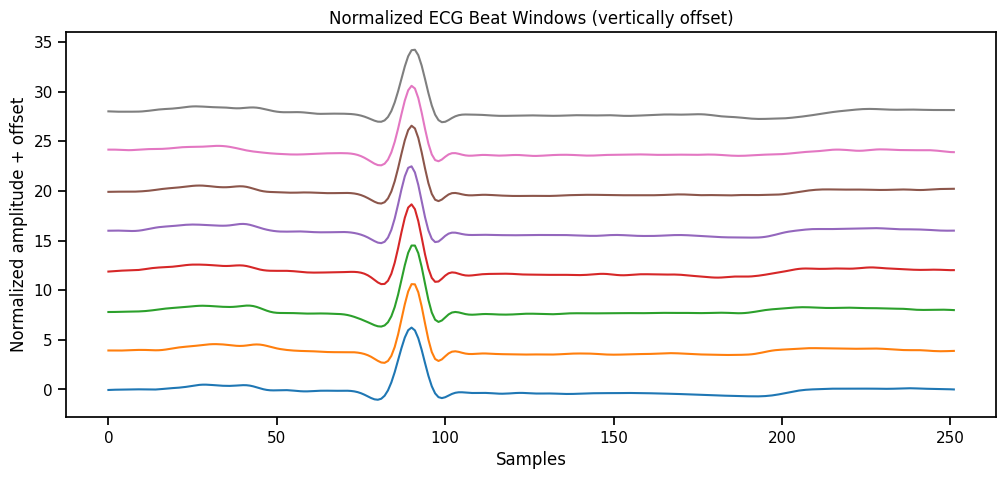

In [45]:
# Visualize a few normalized beat windows
plt.figure(figsize=(12, 5))
for i in range(min(8, len(X100))):
    plt.plot(X100[i] + i * 4, label=str(y100[i]))
plt.title("Normalized ECG Beat Windows (vertically offset)")
plt.xlabel("Samples")
plt.ylabel("Normalized amplitude + offset")
plt.show()

In [46]:
# Feature engineering: morphology + RR intervals
def ecg_feature_table(windows, labels, peak_samples, fs):
    rows = []

    rr_prev = np.diff(peak_samples, prepend=np.nan) / fs
    rr_next = np.diff(peak_samples, append=np.nan) / fs

    for i, (w, lab) in enumerate(zip(windows, labels)):
        rows.append({
            "label": lab,
            "mean": float(np.mean(w)),
            "std": float(np.std(w)),
            "min": float(np.min(w)),
            "max": float(np.max(w)),
            "peak_to_peak": float(np.ptp(w)),
            "energy": float(np.mean(w ** 2)),
            "abs_area": float(np.mean(np.abs(w))),
            "rr_prev_sec": float(rr_prev[i]) if not np.isnan(rr_prev[i]) else np.nan,
            "rr_next_sec": float(rr_next[i]) if not np.isnan(rr_next[i]) else np.nan,
        })

    return pd.DataFrame(rows)

ecg_features = ecg_feature_table(X100, y100, peaks100, fs100)
display(ecg_features.head())
display(ecg_features.groupby("label").mean(numeric_only=True).round(3).head(10))

,label,mean,std,min,max,peak_to_peak,energy,abs_area,rr_prev_sec,rr_next_sec
0,N,0.000000e+00,1.0,-1.035176,6.233121,7.268298,1.0,0.470263,NaN,0.811111
1,N,0.000000e+00,1.0,-1.317814,6.608862,7.926677,1.0,0.470687,0.811111,0.788889
2,N,-3.784422e-09,1.0,-1.662758,6.498566,8.161324,1.0,0.480461,0.788889,0.791667
3,N,0.000000e+00,1.0,-1.386712,6.647662,8.034374,1.0,0.498360,0.791667,0.788889
4,N,0.000000e+00,1.0,-1.259521,6.477726,7.737248,1.0,0.519118,0.788889,0.816667


,mean,std,min,max,peak_to_peak,energy,abs_area,rr_prev_sec,rr_next_sec
label,,,,,,,,,
A,-0.0,1.0,-1.303,6.417,7.720,1.0,0.484,0.594,0.964
N,-0.0,1.0,-1.283,6.388,7.671,1.0,0.499,0.798,0.792
V,0.0,1.0,-3.568,1.541,5.109,1.0,0.652,0.536,1.131


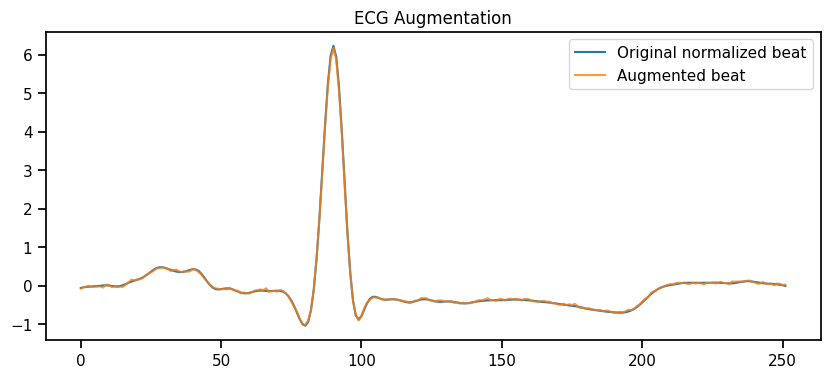

In [47]:
# Conservative ECG augmentation
def augment_ecg_window(w, noise_std=0.02, scale_range=(0.95, 1.05), max_shift=5):
    out = w.copy()

    # amplitude scaling
    scale = np.random.uniform(*scale_range)
    out = out * scale

    # small Gaussian sensor noise
    out = out + np.random.normal(0, noise_std, size=out.shape)

    # small temporal shift
    shift = np.random.randint(-max_shift, max_shift + 1)
    out = np.roll(out, shift)

    return out.astype(np.float32)

example_original = X100[0]
example_augmented = augment_ecg_window(example_original)

plt.figure(figsize=(10, 4))
plt.plot(example_original, label="Original normalized beat")
plt.plot(example_augmented, alpha=0.8, label="Augmented beat")
plt.title("ECG Augmentation")
plt.legend()
plt.show()

In [48]:
# Build a larger model-ready ECG sample from multiple records.
# Increase MAX_RECORDS if you want to process more/all 48 records.
MAX_RECORDS = 10

all_windows = []
all_labels = []

for r in records[:MAX_RECORDS]:
    try:
        Xr, yr, _, _ = extract_windows_from_record(r)
        all_windows.append(Xr)
        all_labels.append(yr)
        print(r, Xr.shape)
    except Exception as e:
        print("Skipped", r, "because:", e)

X_ecg = np.concatenate(all_windows, axis=0)
y_ecg = np.concatenate(all_labels, axis=0)

print("\nCombined ECG windows:", X_ecg.shape)
print(pd.Series(y_ecg).value_counts().head(15))

100 (2271, 252)
101 (1864, 252)
102 (2186, 252)
103 (2083, 252)
104 (2227, 252)
105 (2572, 252)
106 (2027, 252)
107 (2137, 252)
108 (1762, 252)
109 (2531, 252)

Combined ECG windows: (21660, 252)
N    12210
/     5483
L     2491
f      722
V      682
A       42
Q       25
F        4
j        1
Name: count, dtype: int64


In [49]:
# Model-ready tensor: [samples, channels, time]
X_ecg_tensor = torch.tensor(X_ecg[:, None, :], dtype=torch.float32)

# Encode raw beat symbols as integer labels
ecg_classes = sorted(np.unique(y_ecg))
label_to_id = {label: i for i, label in enumerate(ecg_classes)}
y_ecg_ids = np.array([label_to_id[x] for x in y_ecg], dtype=np.int64)
y_ecg_tensor = torch.tensor(y_ecg_ids, dtype=torch.long)

print("ECG classes:", label_to_id)
print("X ECG tensor:", X_ecg_tensor.shape)
print("y ECG tensor:", y_ecg_tensor.shape)

ECG classes: {np.str_('/'): 0, np.str_('A'): 1, np.str_('F'): 2, np.str_('L'): 3, np.str_('N'): 4, np.str_('Q'): 5, np.str_('V'): 6, np.str_('f'): 7, np.str_('j'): 8}
X ECG tensor: torch.Size([21660, 1, 252])
y ECG tensor: torch.Size([21660])


# Healthcare Data Rigor — Key Findings

Healthcare data requires stricter preprocessing than generic datasets because errors can look superficially valid while being clinically wrong.

### Tabular
- A numeric `0` may represent missingness rather than a physiological value.
- Extreme values may be true pathology, so blindly deleting outliers is dangerous.
- Class imbalance can bias a classifier toward the majority outcome.

### Text
- Free-text notes can contain PHI and identifiers.
- Naive text augmentation can alter clinical meaning.
- Specialty labels may be highly imbalanced.

### Images
- Images may have inconsistent resolution, channel format, or embedded metadata.
- Duplicates across splits can cause data leakage.
- Aggressive augmentation can create anatomically implausible images.
- Patient-level splitting is preferable to image-level random splitting when patient IDs are available.

### ECG Signals
- Baseline wander and high-frequency noise distort morphology.
- Beat classes are strongly imbalanced.
- Window boundaries and sampling rate must be handled consistently.
- Excessive filtering or augmentation can destroy diagnostically important waveform structure.

# Final Assignment Checklist

| Requirement | Where completed |
|---|---|
| Acquire 4 real medical datasets/modalities | Parts A-D |
| Inspect raw data | First cells of every part |
| Implausible clinical values | Part A |
| PHI removal | Part B |
| Imaging metadata anonymization | Part C |
| Scaled tensor | Part A |
| Token sequences | Part B |
| Image tensors | Part C |
| ECG signal windows | Part D |
| Hypothesis test | Part A — Welch t-test |
| Chi-square test | Part A — BMI category vs Outcome |
| ANOVA | Part A — Glucose across age groups |
| EDA | All four parts |
| Feature engineering | Parts A and D |
| Feature selection | Parts A and B |
| Feature extraction | Parts B and C |
| Noise removal | Parts C and D |
| Augmentation | Parts C and D |
| Class imbalance discussion | Parts A, B, C, D |
| Healthcare-specific rigor | Final discussion |

In [50]:
print("Assignment notebook pipeline complete.")
print("Before submission: run Runtime > Run all, check every output, and save/export the executed notebook.")

Assignment notebook pipeline complete.
Before submission: run Runtime > Run all, check every output, and save/export the executed notebook.
